# Part A — Exploratory Survival Analysis (Prepayment)

**(i)** Kaplan-Meier survival estimates for prepayment.
**(ii)** Implied hazard rates (discrete monthly + smoothed).
**(iii)** Stratified survival/hazard curves across FICO, LTV, DTI, vintage,
     original interest rate, loan purpose, and origination channel.
**(iv)** Robustness diagnostics: competing-risks CIF, bin-free Cox ranking,
     age × calendar heatmap.

All plots saved to `../figures/` as PNG for presentation use.

**On non-prepayment terminations.** Defaults and other terminations are treated
as right-censored observations for prepayment survival, which is the standard
single-event KM approach. This overstates cumulative prepayment incidence
because it implicitly assumes defaulted loans would have prepaid at the same
rate as survivors. The Aalen-Johansen section at the end shows the correct
competing-risks decomposition.


In [20]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

import gc
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from lifelines.statistics import multivariate_logrank_test
from lifelines.utils import survival_table_from_events
from src.credit_data import load_loans, load_outcomes

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
print("repo:", REPO_ROOT)
print("figures →", FIGURES_DIR)


repo: c:\Users\a\Desktop\Credit\Project2
figures → c:\Users\a\Desktop\Credit\Project2\figures


In [21]:
YEARS = list(range(2006, 2023))   # in-sample vintages

# Numeric covariates — cut into labelled bins.
# Edit breaks/labels to change stratification; rest of notebook adapts.
COVARIATE_BINS = {
    "fico": {
        "breaks": [660, 700, 740, 780],
        "labels": ["<660", "660-700", "700-740", "740-780", "780+"],
    },
    "ltv": {
        "breaks": [60, 80, 90, 95],
        "labels": ["≤60", "60-80", "80-90", "90-95", "95+"],
    },
    "dti": {
        "breaks": [30, 40, 45],
        "labels": ["≤30", "30-40", "40-45", "45+"],
    },
    "orig_rate": {
        "breaks": [3.5, 4.5, 5.5, 6.5],
        "labels": ["<3.5%", "3.5-4.5%", "4.5-5.5%", "5.5-6.5%", "6.5%+"],
    },
}

# Categorical covariates — define as explicit Polars expression masks.
LOAN_PURPOSE_GROUPS = {
    "Purchase (P)":      pl.col("loan_purpose") == "P",
    "No-cash refi (N)":  pl.col("loan_purpose") == "N",
    "Cash-out refi (C)": pl.col("loan_purpose") == "C",
}
CHANNEL_GROUPS = {
    "Retail (R)":        pl.col("channel") == "R",
    "Broker (B)":        pl.col("channel") == "B",
    "Correspondent (T)": pl.col("channel") == "T",
    "TPO/Other (C)":     pl.col("channel") == "C",
}
VINTAGE_GROUPS = {
    "2006-2008 (crisis)":   [2006, 2007, 2008],
    "2009-2014 (recovery)": [2009, 2010, 2011, 2012, 2013, 2014],
    "2015-2019 (low-rate)": [2015, 2016, 2017, 2018, 2019],
    "2020-2022 (covid)":    [2020, 2021, 2022],
}

MAX_MONTHS      = 240    # upper horizon cap
SMOOTH_BW       = 3      # months, centered rolling-mean smoother window
SAMPLE_PER_GROUP = 500_000  # per-group cap for stratified plots (RAM)

# AT_RISK_FLOOR: the plot horizon is auto-truncated at the month where the
# at-risk pool first falls below this threshold. Set to 0 to disable.
AT_RISK_FLOOR = 100_000

# Initialised here; updated after aggregate KM is computed.
EFFECTIVE_MAX_MONTHS = MAX_MONTHS

# Accumulates one log-rank summary per plot_stratified() call.
LOGRANK_RESULTS: list[dict] = []


In [22]:
loans = (
    load_loans(
        years=YEARS,
        columns=[
            "vintage_year",
            "fico", "ltv", "dti", "orig_rate",
            "loan_purpose", "channel",
            "event_type", "event_time_months",
        ],
    )
    .with_columns(
        (pl.col("event_type") == "prepaid").cast(pl.Int8).alias("prepay_observed"),
    )
    .filter(pl.col("event_time_months").is_not_null())
)
print(f"loans loaded: {loans.height:,} rows  vintages {YEARS[0]}-{YEARS[-1]}")
print("event_type distribution:")
print(loans.group_by("event_type").len().sort("len", descending=True))
print(f"\noverall prepayment rate: {loans['prepay_observed'].mean():.3f}")
loans = loans.drop("event_type")


loans loaded: 23,212,251 rows  vintages 2006-2022
event_type distribution:
shape: (4, 2)
┌───────────────────┬──────────┐
│ event_type        ┆ len      │
│ ---               ┆ ---      │
│ str               ┆ u32      │
╞═══════════════════╪══════════╡
│ prepaid           ┆ 13739015 │
│ censored          ┆ 8755751  │
│ defaulted         ┆ 643128   │
│ other_termination ┆ 74357    │
└───────────────────┴──────────┘

overall prepayment rate: 0.592


## (i) Aggregate Kaplan-Meier survival for prepayment

S(t) = P(loan has not prepaid by month t).

The x-axis is truncated where the at-risk pool drops below `AT_RISK_FLOOR` loans —
below that count, the discrete hazard estimator is too noisy to be meaningful.


Effective horizon: 175 months  (at-risk ≥ 100,000  |  floor at 100,000 loans)


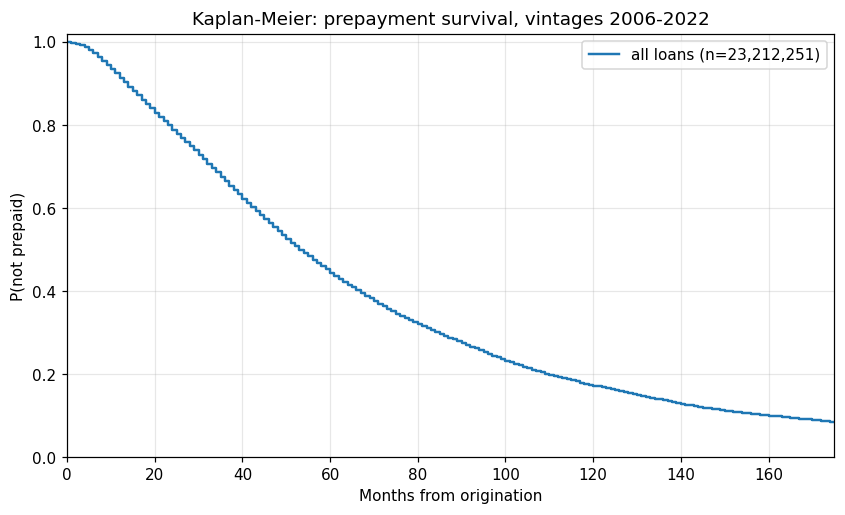

S( 12 mo) ≈ 0.914
S( 36 mo) ≈ 0.664
S( 60 mo) ≈ 0.445
S(120 mo) ≈ 0.173
S(180 mo) ≈ 0.079


18

In [23]:
dur = loans["event_time_months"].to_numpy()
evt = loans["prepay_observed"].to_numpy()

table_agg = survival_table_from_events(dur, evt)
table_agg = table_agg[table_agg.index <= MAX_MONTHS]
hazard_agg  = (table_agg["observed"] / table_agg["at_risk"]).rename("hazard")
S_agg       = (1.0 - hazard_agg).cumprod().rename("survival")

# Auto-truncate: find last month with enough at-risk loans.
if AT_RISK_FLOOR > 0:
    eligible = table_agg.index[table_agg["at_risk"] >= AT_RISK_FLOOR]
    EFFECTIVE_MAX_MONTHS = int(eligible.max()) if len(eligible) else MAX_MONTHS
else:
    EFFECTIVE_MAX_MONTHS = MAX_MONTHS
print(f"Effective horizon: {EFFECTIVE_MAX_MONTHS} months  "
      f"(at-risk ≥ {AT_RISK_FLOOR:,}  |  floor at {AT_RISK_FLOOR:,} loans)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(S_agg.index, S_agg.values, where="post", lw=1.6,
        label=f"all loans (n={len(dur):,})")
ax.set_xlim(0, EFFECTIVE_MAX_MONTHS)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Months from origination")
ax.set_ylabel("P(not prepaid)")
ax.set_title(f"Kaplan-Meier: prepayment survival, vintages {YEARS[0]}-{YEARS[-1]}")
ax.grid(alpha=0.3); ax.legend()
fig.savefig(FIGURES_DIR / "partA_km_aggregate.png")
plt.show(); plt.close(fig)

for t in (12, 36, 60, 120, 180):
    avail = S_agg.index[S_agg.index <= t]
    if len(avail):
        print(f"S({t:>3} mo) ≈ {S_agg.loc[avail.max()]:.3f}")

del dur, evt
gc.collect()


## (ii) Implied hazard rates

Both panels are derived from the same lifetable. The right tail is truncated
at `EFFECTIVE_MAX_MONTHS` (the horizon where at-risk loans ≥ `AT_RISK_FLOOR`).
Beyond that point the discrete `events / at_risk` estimator is dominated by
sampling noise rather than the underlying prepayment rate.


C:\Users\a\AppData\Local\Temp\ipykernel_11836\3003248836.py:8: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  axes[0].plot(discrete_hazard[:EFFECTIVE_MAX_MONTHS].index,
C:\Users\a\AppData\Local\Temp\ipykernel_11836\3003248836.py:9: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  discrete_hazard[:EFFECTIVE_MAX_MONTHS].values * 100, lw=1.0)
C:\Users\a\AppData\Local\Temp\ipykernel_11836\3003248836.py:15: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  axes[1].plot(smoothed[:EFFECTIVE_MAX_MONTHS].index,
C:

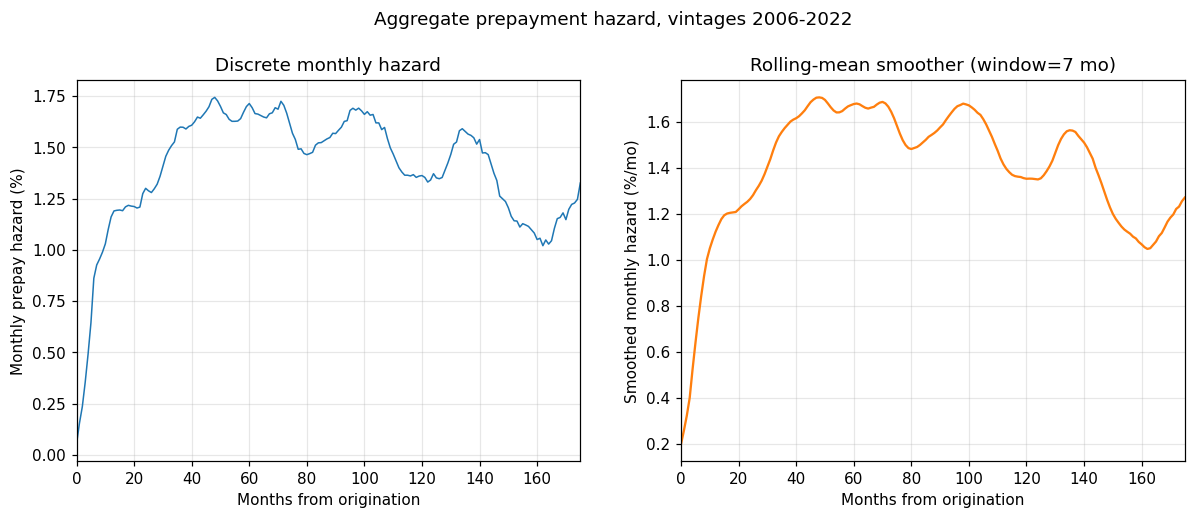

peak hazard: 1.74% at month 48.0
at-risk at truncation point (mo 175): 103,346


6899

In [24]:
window = max(1, 2 * SMOOTH_BW + 1)
discrete_hazard = hazard_agg
smoothed = discrete_hazard.rolling(window=window, center=True, min_periods=1).mean()
at_risk  = table_agg["at_risk"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(discrete_hazard[:EFFECTIVE_MAX_MONTHS].index,
             discrete_hazard[:EFFECTIVE_MAX_MONTHS].values * 100, lw=1.0)
axes[0].set_xlabel("Months from origination")
axes[0].set_ylabel("Monthly prepay hazard (%)")
axes[0].set_title("Discrete monthly hazard")
axes[0].set_xlim(0, EFFECTIVE_MAX_MONTHS); axes[0].grid(alpha=0.3)

axes[1].plot(smoothed[:EFFECTIVE_MAX_MONTHS].index,
             smoothed[:EFFECTIVE_MAX_MONTHS].values * 100, lw=1.5, color="tab:orange")
axes[1].set_xlabel("Months from origination")
axes[1].set_ylabel("Smoothed monthly hazard (%/mo)")
axes[1].set_title(f"Rolling-mean smoother (window={window} mo)")
axes[1].set_xlim(0, EFFECTIVE_MAX_MONTHS); axes[1].grid(alpha=0.3)

fig.suptitle(f"Aggregate prepayment hazard, vintages {YEARS[0]}-{YEARS[-1]}", y=1.02)
fig.savefig(FIGURES_DIR / "partA_hazard_aggregate.png")
plt.show(); plt.close(fig)

print(f"peak hazard: {discrete_hazard.max()*100:.2f}% at month {discrete_hazard.idxmax()}")
print(f"at-risk at truncation point (mo {EFFECTIVE_MAX_MONTHS}): "
      f"{int(at_risk.loc[EFFECTIVE_MAX_MONTHS]):,}" if EFFECTIVE_MAX_MONTHS in at_risk.index
      else "")
gc.collect()


## (iii) Stratified survival and hazard by covariate

For each covariate the left panel shows KM survival curves and the right shows
the smoothed monthly hazard, both truncated at `EFFECTIVE_MAX_MONTHS`. The
log-rank p-values and chi-squared statistics are printed inline and collected
for the summary panel at the end.


In [25]:
def _lifetable(d, e, max_m):
    t = survival_table_from_events(d, e)
    t = t[t.index <= max_m]
    h = (t["observed"] / t["at_risk"]).rename("hazard")
    s = (1.0 - h).cumprod().rename("survival")
    return h, s


def plot_stratified(loans_df, group_col, save_stem,
                    bin_cfg=None, explicit_groups=None,
                    title=None, smooth_bw=SMOOTH_BW,
                    max_months=None, sample_per_group=SAMPLE_PER_GROUP):
    """KM + smoothed hazard stratified by group_col; log-rank appended to LOGRANK_RESULTS."""
    if max_months is None:
        max_months = EFFECTIVE_MAX_MONTHS

    if bin_cfg is not None:
        df = (loans_df
              .filter(pl.col(group_col).is_not_null())
              .with_columns(pl.col(group_col)
                              .cut(breaks=bin_cfg["breaks"], labels=bin_cfg["labels"])
                              .alias("__grp")))
        ordered_groups = bin_cfg["labels"]
    elif explicit_groups is not None:
        cols = []
        ordered_groups = list(explicit_groups.keys())
        for label, mask in explicit_groups.items():
            cols.append(pl.when(mask).then(pl.lit(label)).otherwise(None))
        df = (loans_df
              .with_columns(pl.coalesce(cols).alias("__grp"))
              .filter(pl.col("__grp").is_not_null()))
    else:
        raise ValueError("provide bin_cfg or explicit_groups")

    if sample_per_group is not None:
        parts = []
        for grp in ordered_groups:
            sub = df.filter(pl.col("__grp") == grp)
            if sub.height > sample_per_group:
                sub = sub.sample(n=sample_per_group, seed=0)
            parts.append(sub)
        df = pl.concat(parts)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cmap   = plt.cm.viridis(np.linspace(0.0, 0.9, len(ordered_groups)))
    window = max(1, 2 * smooth_bw + 1)

    for color, label in zip(cmap, ordered_groups):
        sub = df.filter(pl.col("__grp") == label)
        if sub.height < 100:
            continue
        d = sub["event_time_months"].to_numpy()
        e = sub["prepay_observed"].to_numpy()
        h, s = _lifetable(d, e, max_months)
        smooth = h.rolling(window=window, center=True, min_periods=1).mean()
        axes[0].step(s.index, s.values, where="post",
                     color=color, lw=1.4, label=f"{label} (n={sub.height:,})")
        axes[1].plot(smooth.index, smooth.values * 100,
                     color=color, lw=1.4, label=label)
        del sub, d, e, h, s, smooth
        gc.collect()

    axes[0].set_xlim(0, max_months); axes[0].set_ylim(0, 1.02)
    axes[0].set_xlabel("Months from origination")
    axes[0].set_ylabel("P(not prepaid)")
    axes[0].set_title(f"KM by {group_col}"); axes[0].grid(alpha=0.3); axes[0].legend()
    axes[1].set_xlim(0, max_months)
    axes[1].set_xlabel("Months from origination")
    axes[1].set_ylabel("Smoothed hazard (%/mo)")
    axes[1].set_title(f"Hazard by {group_col}"); axes[1].grid(alpha=0.3); axes[1].legend()
    fig.suptitle(title or f"Prepayment by {group_col}", y=1.02)
    fig.savefig(FIGURES_DIR / f"partA_strat_{save_stem}.png")
    plt.show(); plt.close(fig)

    pdf = (df.select(["event_time_months", "prepay_observed", "__grp"])
             .drop_nulls().to_pandas())
    res = multivariate_logrank_test(
        pdf["event_time_months"], pdf["__grp"], pdf["prepay_observed"])
    summary = {
        "covariate": save_stem,
        "n_groups":  int(pdf["__grp"].nunique()),
        "n_loans":   int(len(pdf)),
        "chi2":      float(res.test_statistic),
        "p_value":   float(res.p_value),
    }
    LOGRANK_RESULTS.append(summary)
    print(f"  log-rank: chi2={summary['chi2']:,.1f}  p={summary['p_value']:.2e}  "
          f"n_groups={summary['n_groups']}  n={summary['n_loans']:,}")
    del df, pdf, res, fig, axes
    gc.collect()
    return summary


### FICO

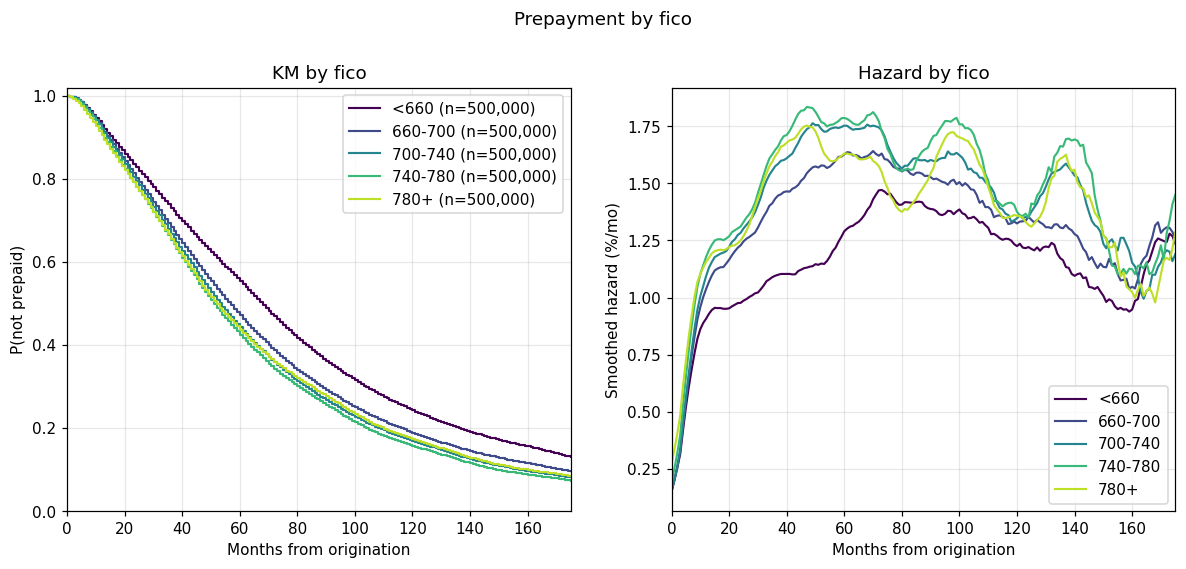

  log-rank: chi2=16,423.1  p=0.00e+00  n_groups=5  n=2,500,000


In [26]:
plot_stratified(loans, "fico", save_stem="fico", bin_cfg=COVARIATE_BINS["fico"]);

### LTV

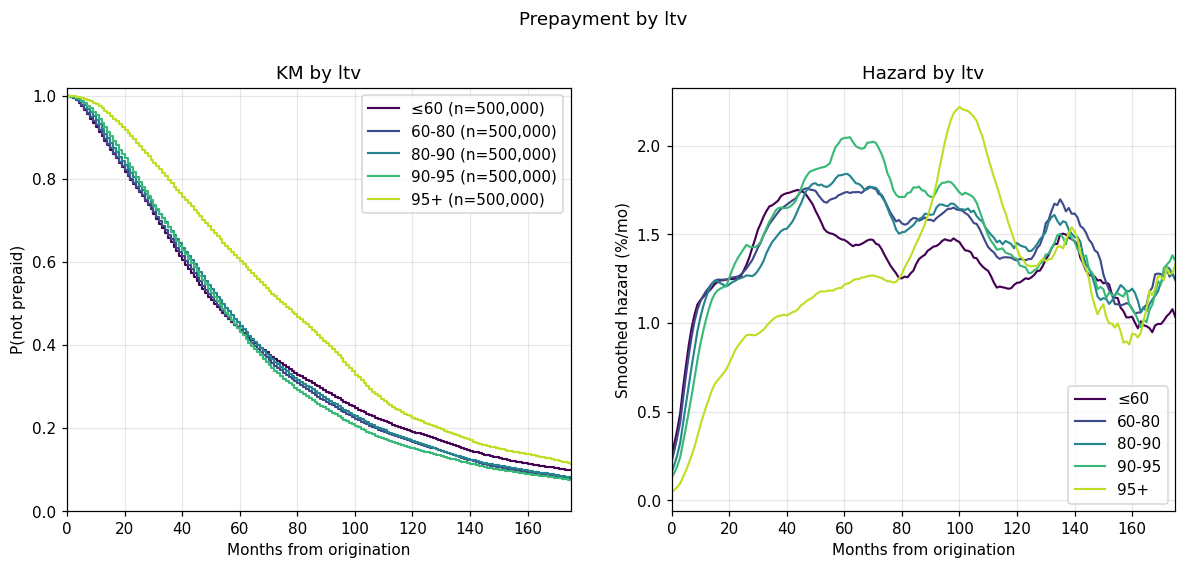

  log-rank: chi2=29,693.4  p=0.00e+00  n_groups=5  n=2,500,000


In [27]:
plot_stratified(loans, "ltv", save_stem="ltv", bin_cfg=COVARIATE_BINS["ltv"]);

### DTI

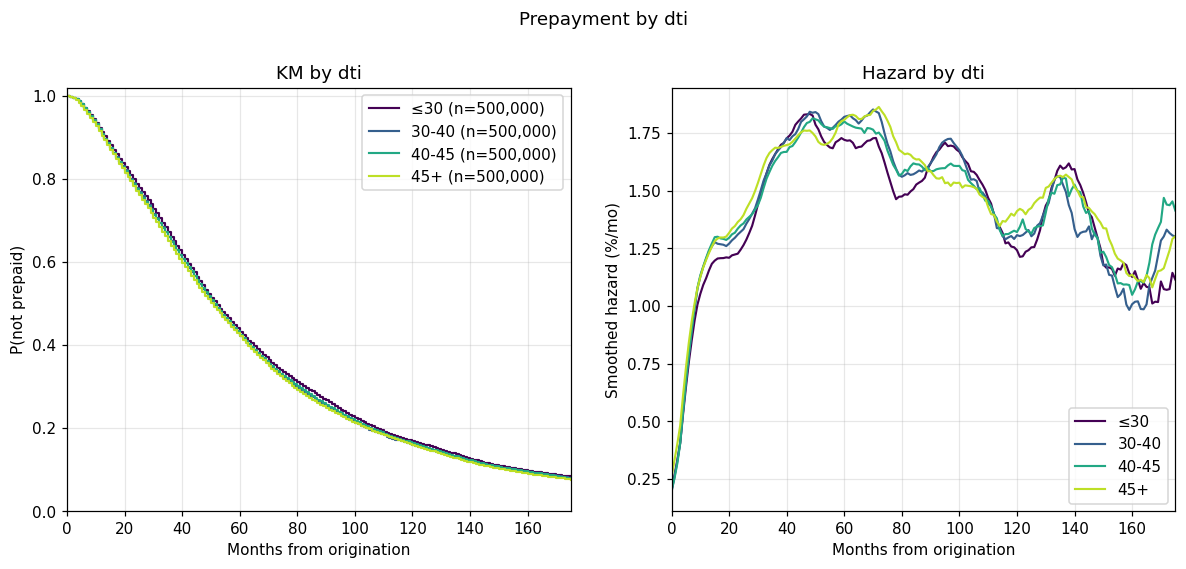

  log-rank: chi2=398.5  p=4.66e-86  n_groups=4  n=2,000,000


In [28]:
plot_stratified(loans, "dti", save_stem="dti", bin_cfg=COVARIATE_BINS["dti"]);

### Vintage group

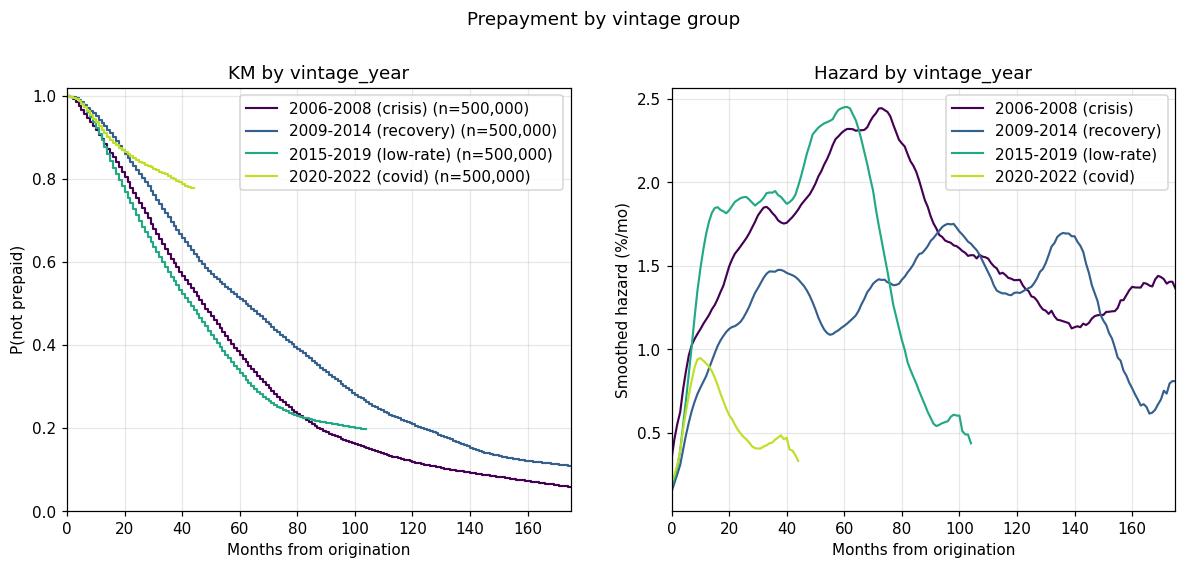

  log-rank: chi2=62,588.2  p=0.00e+00  n_groups=4  n=2,000,000


In [29]:
plot_stratified(loans, "vintage_year", save_stem="vintage",
                explicit_groups={lbl: pl.col("vintage_year").is_in(yrs) for lbl, yrs in VINTAGE_GROUPS.items()},
                title="Prepayment by vintage group");

### Original interest rate

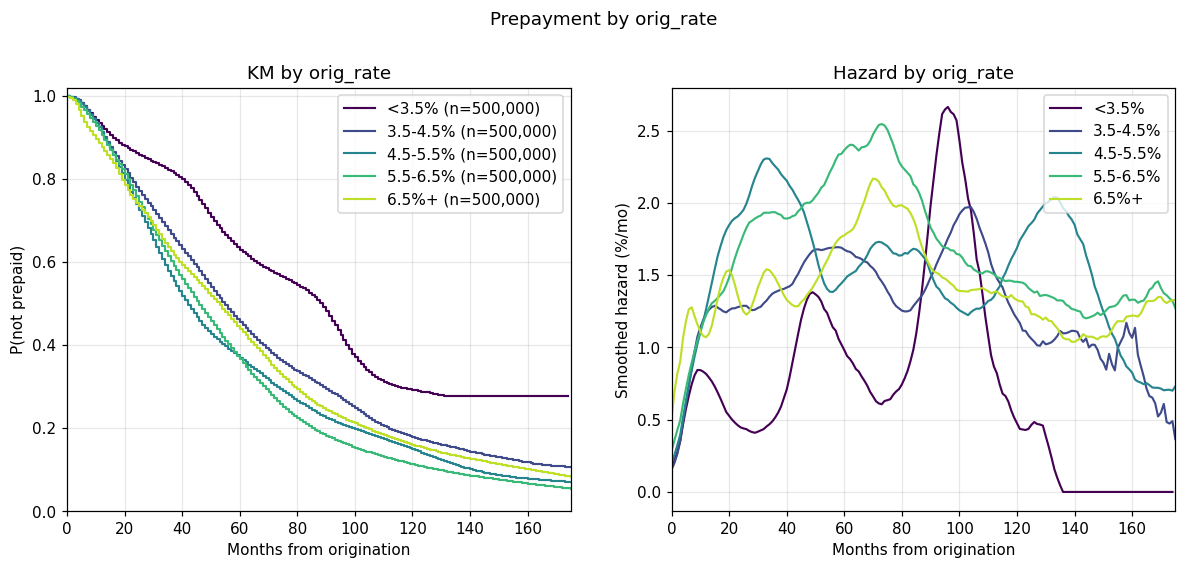

  log-rank: chi2=60,913.1  p=0.00e+00  n_groups=5  n=2,500,000


In [30]:
plot_stratified(loans, "orig_rate", save_stem="orig_rate", bin_cfg=COVARIATE_BINS["orig_rate"]);

### Loan purpose

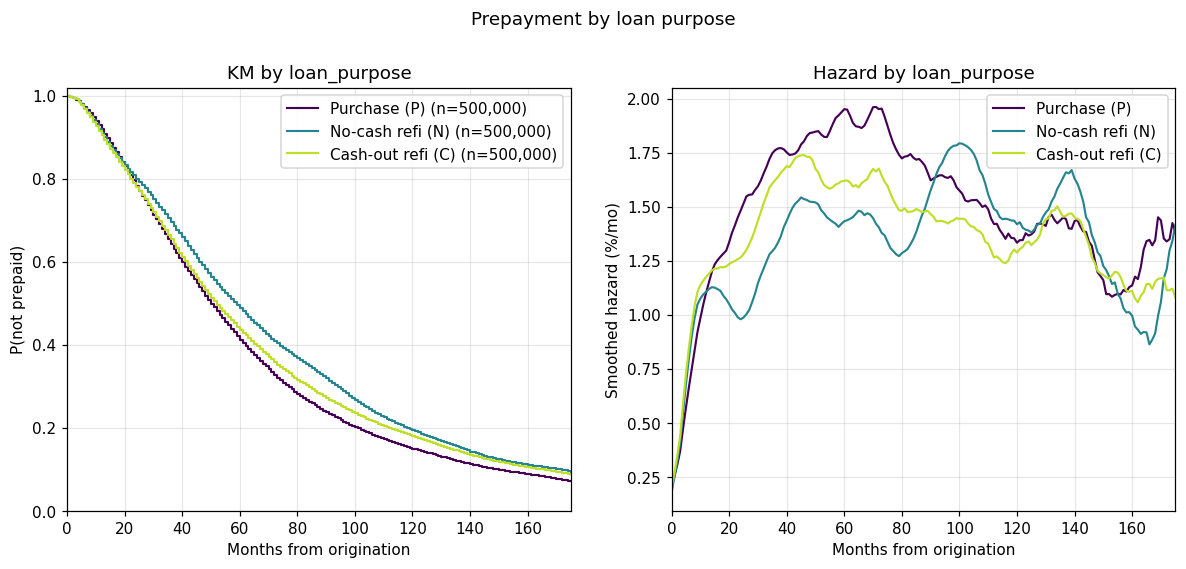

  log-rank: chi2=4,191.9  p=0.00e+00  n_groups=3  n=1,500,000


In [31]:
plot_stratified(loans, "loan_purpose", save_stem="loan_purpose",
                explicit_groups=LOAN_PURPOSE_GROUPS, title="Prepayment by loan purpose");

### Origination channel

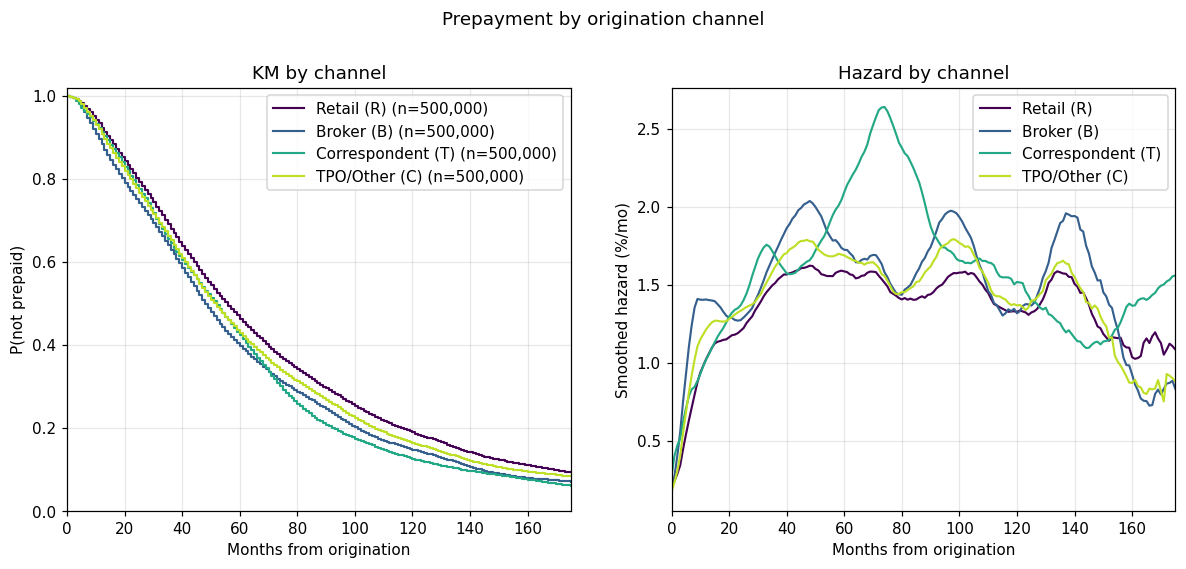

  log-rank: chi2=6,633.4  p=0.00e+00  n_groups=4  n=2,000,000


In [32]:
plot_stratified(loans, "channel", save_stem="channel",
                explicit_groups=CHANNEL_GROUPS, title="Prepayment by origination channel");

## Statistical comparison — log-rank tests

With n ≈ 13M the p-value is essentially zero for every covariate; what matters is
the relative magnitude of chi². Log-rank chi² scales linearly with n, so the bar
chart gives the *ranking* of each covariate's univariate power to separate survival
curves, not an absolute significance test.

Key caveat: vintage absorbs most of the rate-cycle variation (calendar time = refi
incentive = vintage × current rate). Its large chi² will shrink substantially once
time-varying rate incentive is included as a covariate in the Cox model (Part B).

Log-rank also assumes proportional hazards; covariates whose group curves cross
(e.g. high-LTV bursting early vs. low-LTV being more persistent) may have their
effect understated.


In [33]:
results = (
    pd.DataFrame(LOGRANK_RESULTS)
    .sort_values("chi2", ascending=False)
    .reset_index(drop=True)
)
rd = results.copy()
rd["chi2"]    = rd["chi2"].round(1)
rd["p_value"] = rd["p_value"].apply(lambda p: f"{p:.2e}")
rd.to_csv(FIGURES_DIR / "partA_logrank_results.csv", index=False)
print("saved:", FIGURES_DIR / "partA_logrank_results.csv")
rd


saved: c:\Users\a\Desktop\Credit\Project2\figures\partA_logrank_results.csv


,covariate,n_groups,n_loans,chi2,p_value
0,vintage,4,2000000,62588.2,0.00e+00
1,orig_rate,5,2500000,60913.1,0.00e+00
2,ltv,5,2500000,29693.4,0.00e+00
3,fico,5,2500000,16423.1,0.00e+00
4,channel,4,2000000,6633.4,0.00e+00
5,loan_purpose,3,1500000,4191.9,0.00e+00
6,dti,4,2000000,398.5,4.66e-86


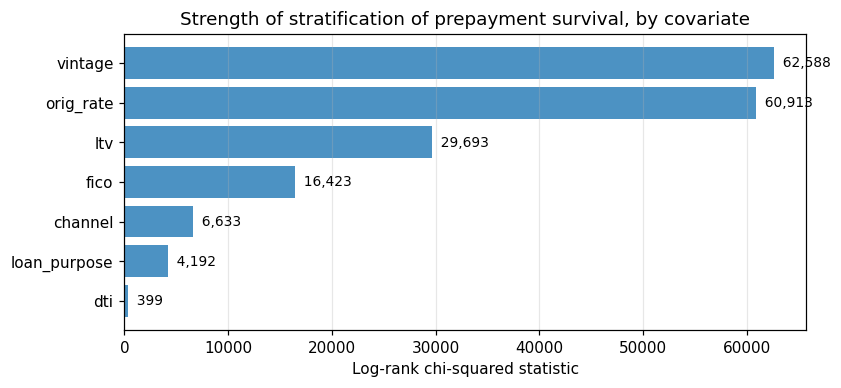

In [34]:
fig, ax = plt.subplots(figsize=(8, 3.5))
order = results.sort_values("chi2")
ax.barh(order["covariate"], order["chi2"], color="tab:blue", alpha=0.8)
for i, (cov, chi2) in enumerate(zip(order["covariate"], order["chi2"])):
    ax.text(chi2, i, f"  {chi2:,.0f}", va="center", fontsize=9)
ax.set_xlabel("Log-rank chi-squared statistic")
ax.set_title("Strength of stratification of prepayment survival, by covariate")
ax.grid(axis="x", alpha=0.3)
fig.savefig(FIGURES_DIR / "partA_logrank_summary.png")
plt.show(); plt.close(fig)


## How to customise

- **Different bins** — edit `COVARIATE_BINS` (breaks + labels) or `*_GROUPS` dicts.
- **Different vintage groups** — edit `VINTAGE_GROUPS`.
- **Horizon** — `AT_RISK_FLOOR` drives auto-truncation; set to 0 to disable.
- **Smoother** — `SMOOTH_BW` months.
- **Vintages** — `YEARS` (add 2024-2025 for held-out eval).
- **RAM** — `SAMPLE_PER_GROUP` (default 500k; raise or set to None for full-precision).
- **New covariate** — call `plot_stratified(loans, "col", save_stem="col", bin_cfg=...)`.


---
## Diagnostics and robustness

The three sections below address methodological questions about the KM results above.


### Competing risks: Aalen-Johansen cumulative incidence functions

KM treats defaulted/other-terminated loans as censored observations, implicitly
assuming they would have prepayed at the same rate as survivors — an assumption
that is unlikely to hold (low-FICO, high-LTV borrowers who default would have been
slower prepayers). The **cumulative incidence function** (CIF) from the
Aalen-Johansen estimator is the correct quantity: the probability that a loan
terminates *due to cause k specifically* by month t, in the presence of
competing events.

CIF_prepay + CIF_default + CIF_other ≤ 1 at each t; the gap is the probability
of still being active. Compare 1 − S_KM (above) with CIF_prepay here: KM
overstates the cumulative prepayment probability to the extent that it ignores
the competitor (default).


c:\Users\a\anaconda3\envs\quant\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
c:\Users\a\anaconda3\envs\quant\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
c:\Users\a\anaconda3\envs\quant\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
C:\Users\a\AppData\Local\Temp\ipykernel_11836\2739612900.py:28: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this

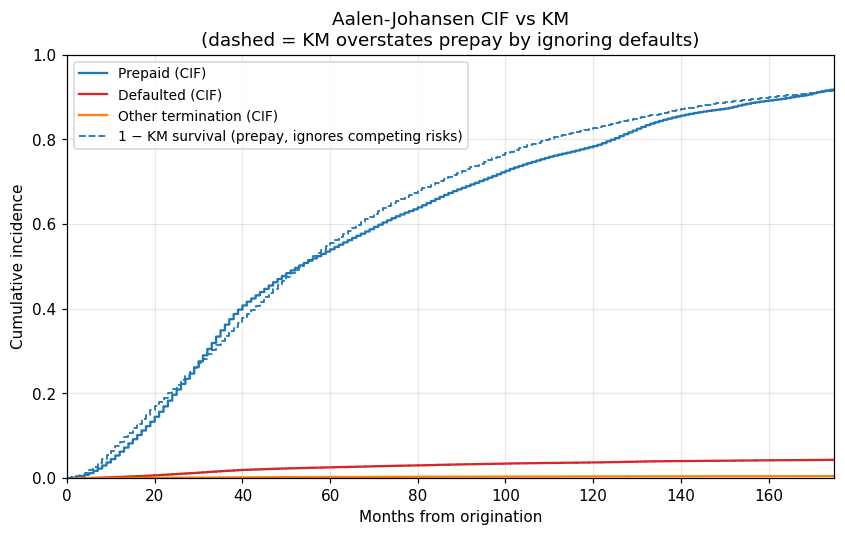

8037

In [36]:
from lifelines import AalenJohansenFitter

aj_raw = (
    load_outcomes(years=YEARS, columns=["event_time_months", "event_type"])
    .filter(pl.col("event_time_months").is_not_null())
    .to_pandas()
)
if len(aj_raw) > 1_000_000:
    aj_raw = aj_raw.sample(1_000_000, random_state=0)

event_map = {"censored": 0, "prepaid": 1, "defaulted": 2, "other_termination": 3}
aj_raw["event_code"] = aj_raw["event_type"].map(event_map).fillna(0).astype(int)

T = aj_raw["event_time_months"]
E = aj_raw["event_code"]

fig, ax = plt.subplots(figsize=(9, 5))
cause_labels = {
    1: ("Prepaid (CIF)",           "tab:blue"),
    2: ("Defaulted (CIF)",         "tab:red"),
    3: ("Other termination (CIF)", "tab:orange"),
}
for cause, (label, color) in cause_labels.items():
    ajf = AalenJohansenFitter(calculate_variance=False)
    ajf.fit(T, E, event_of_interest=cause, label=label)
    ajf.plot_cumulative_density(ax=ax, color=color, lw=1.5, ci_show=False)

ax.step(S_agg[:EFFECTIVE_MAX_MONTHS].index,
        1 - S_agg[:EFFECTIVE_MAX_MONTHS].values,
        where="post", color="tab:blue", lw=1.2, ls="--",
        label="1 − KM survival (prepay, ignores competing risks)")

ax.set_xlim(0, EFFECTIVE_MAX_MONTHS); ax.set_ylim(0, 1.0)
ax.set_xlabel("Months from origination")
ax.set_ylabel("Cumulative incidence")
ax.set_title("Aalen-Johansen CIF vs KM\n"
             "(dashed = KM overstates prepay by ignoring defaults)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.savefig(FIGURES_DIR / "partA_competing_risks_cif.png")
plt.show(); plt.close(fig)

del aj_raw, T, E
gc.collect()


### Bin-free univariate Cox ranking

Log-rank test results depend on the choice of bin boundaries. Univariate
proportional-hazards models treat each numeric covariate *continuously*, giving a
ranking that is independent of binning assumptions. The likelihood-ratio chi² from
each univariate Cox fit is the proper bin-free analog of the log-rank statistic.

Interpretation: a larger LR chi² means stronger evidence that the covariate
has a non-zero association with prepayment timing, treating the effect as
log-linear in the covariate. The hazard ratio shows direction and magnitude.


In [37]:
from lifelines import CoxPHFitter

NUMERIC_COVARIATES = ["fico", "ltv", "dti", "orig_rate"]
cox_rows = []

for col in NUMERIC_COVARIATES:
    sub = (
        loans.select(["event_time_months", "prepay_observed", col])
        .drop_nulls()
        .to_pandas()
    )
    if len(sub) > 500_000:
        sub = sub.sample(500_000, random_state=0)
    cph = CoxPHFitter().fit(sub, "event_time_months", "prepay_observed", formula=col)
    lrt = cph.log_likelihood_ratio_test()
    cox_rows.append({
        "covariate":   col,
        "n":           len(sub),
        "hazard_ratio": float(np.exp(cph.params_[col])),
        "cox_lr_chi2": float(lrt.test_statistic),
        "logrank_chi2": next((r["chi2"] for r in LOGRANK_RESULTS if r["covariate"]==col), None),
    })
    del sub
    gc.collect()

cox_df = pd.DataFrame(cox_rows).sort_values("cox_lr_chi2", ascending=False).reset_index(drop=True)
cox_df["cox_lr_chi2"]  = cox_df["cox_lr_chi2"].round(1)
cox_df["hazard_ratio"] = cox_df["hazard_ratio"].round(4)
cox_df


,covariate,n,hazard_ratio,cox_lr_chi2,logrank_chi2
0,orig_rate,500000,1.1857,9559.8,60913.083410
1,fico,500000,1.0011,891.3,16423.058877
2,ltv,500000,0.9981,404.6,29693.359879
3,dti,500000,1.0018,97.0,398.507176


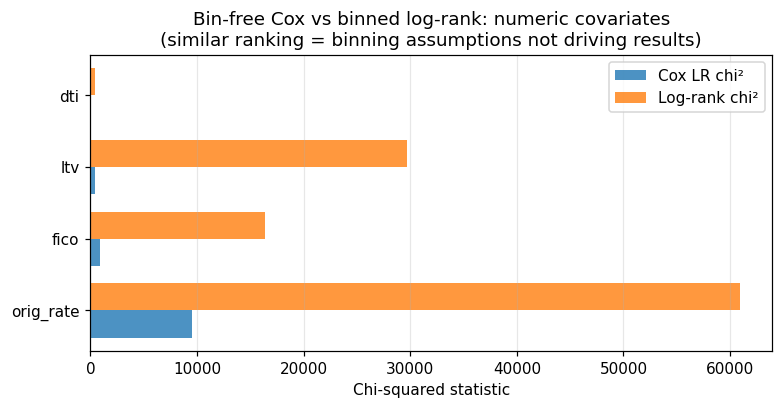

3831

In [38]:
# Side-by-side bar: log-rank chi² vs Cox LR chi² for the numeric covariates.
fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(cox_df))
w = 0.38
ax.barh(x - w/2, cox_df["cox_lr_chi2"],   w, label="Cox LR chi²", color="tab:blue",   alpha=0.8)
ax.barh(x + w/2, cox_df["logrank_chi2"],   w, label="Log-rank chi²", color="tab:orange", alpha=0.8)
ax.set_yticks(x); ax.set_yticklabels(cox_df["covariate"])
ax.set_xlabel("Chi-squared statistic")
ax.set_title("Bin-free Cox vs binned log-rank: numeric covariates\n"
             "(similar ranking = binning assumptions not driving results)")
ax.legend(); ax.grid(axis="x", alpha=0.3)
fig.savefig(FIGURES_DIR / "partA_cox_vs_logrank.png")
plt.show(); plt.close(fig)
gc.collect()


### Age × calendar-year heatmap

The humps in the aggregate hazard curve appear at different loan ages for
different vintages because the same calendar event (e.g. 2020 rate drop) hits
each vintage at a different seasoning stage. This heatmap shows the monthly
prepayment rate as a function of **both** calendar year (rows) and loan age
(columns) simultaneously.

Reading the chart:
- **Horizontal bands** (same colour across ages within one year) = pure period
  effect (rate environment). A 2020 horizontal band well above neighbouring years
  means every age group prepays faster in 2020.
- **Vertical bands** (same colour across years at one age) = pure seasoning/burnout
  effect. A bright column at 36-48 months would mean loans of that age always have
  elevated hazard regardless of the rate environment.
- In practice you see both — the Cox model in Part B decomposes them by including
  time-varying rate incentive as a covariate.

Computed from the outcomes table only — no monthly panel scan required.


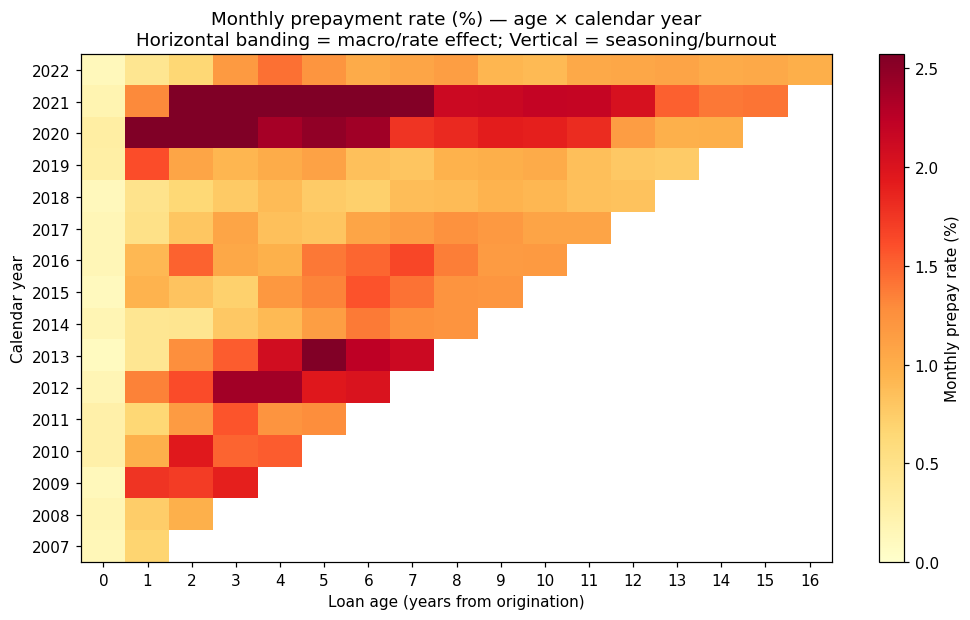

10358

In [39]:
hm = (
    load_outcomes(years=YEARS, columns=["vintage_year", "last_obs_date", "event_type"])
    .filter(pl.col("last_obs_date").is_not_null())
    .with_columns(pl.col("last_obs_date").dt.year().alias("end_year"))
)

# Pre-aggregate to (vintage_year, end_year, event_type) — ~1 600 rows.
summary_pl = (
    hm.group_by(["vintage_year", "end_year", "event_type"])
    .agg(pl.len().alias("n"))
)
sm = summary_pl.to_pandas()
active_sm  = sm.groupby(["vintage_year", "end_year"])["n"].sum().reset_index()
prepaid_sm = sm[sm["event_type"] == "prepaid"][["vintage_year", "end_year", "n"]]

CAL_YEARS  = list(range(2007, 2023))   # calendar years
AGE_YEARS  = list(range(0, 17))        # 0-16 years from origination
MIN_ACTIVE = 2_000                     # sparse cells set to NaN

matrix = np.full((len(CAL_YEARS), len(AGE_YEARS)), np.nan)
for ci, cy in enumerate(CAL_YEARS):
    for ai, ay in enumerate(AGE_YEARS):
        vy = cy - ay   # vintage year for this age × calendar combination
        if vy < YEARS[0] or vy > YEARS[-1]:
            continue
        n_act = int(active_sm[
            (active_sm.vintage_year == vy) & (active_sm.end_year >= cy)
        ]["n"].sum())
        if n_act < MIN_ACTIVE:
            continue
        n_pre = int(prepaid_sm[
            (prepaid_sm.vintage_year == vy) & (prepaid_sm.end_year == cy)
        ]["n"].sum())
        matrix[ci, ai] = n_pre / n_act / 12 * 100   # monthly rate

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(
    matrix,
    aspect="auto",
    origin="lower",
    cmap="YlOrRd",
    vmin=0,
    vmax=np.nanpercentile(matrix, 95),   # cap at 95th pct to avoid outlier wash-out
)
ax.set_xticks(range(len(AGE_YEARS)));  ax.set_xticklabels(AGE_YEARS)
ax.set_yticks(range(len(CAL_YEARS)));  ax.set_yticklabels(CAL_YEARS)
ax.set_xlabel("Loan age (years from origination)")
ax.set_ylabel("Calendar year")
ax.set_title("Monthly prepayment rate (%) — age × calendar year\n"
             "Horizontal banding = macro/rate effect; Vertical = seasoning/burnout")
plt.colorbar(im, ax=ax, label="Monthly prepay rate (%)")
fig.savefig(FIGURES_DIR / "partA_heatmap_age_calendar.png")
plt.show(); plt.close(fig)

del hm, summary_pl, sm, active_sm, prepaid_sm, matrix
gc.collect()


### Per-vintage hazard overlay — the calendar-time smoking gun

If the seasoning hump in the aggregate hazard reflects a *calendar* effect (rate
cycle / refi window) rather than an intrinsic loan-age effect, then each
vintage's hump should appear at a different loan age — specifically the age at
which that vintage was exposed to the rate trough.

Recent vintages (2022) are dropped because their observable history is shorter
than the analysis horizon, so the right-tail estimator is unstable.


In [ ]:
# Per-vintage hazard overlay. Calendar smoking gun.
import gc, numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
from lifelines.utils import survival_table_from_events

SMOOTH = 3
VINTAGE_MIN_MAX_MONTHS = 48  # vintage must be observable for >= 48 mo

vintage_counts = (
    loans
    .filter(pl.col("event_time_months").is_not_null())
    .group_by("vintage_year")
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") >= 20_000)
    .sort("vintage_year")
)
vintages = sorted(vintage_counts["vintage_year"].to_list())

cmap = cm.get_cmap("plasma", len(vintages))
colors = {v: cmap(i) for i, v in enumerate(vintages)}

fig, ax = plt.subplots(figsize=(12, 6))
plotted_vintages = []

for vint in vintages:
    sub = (
        loans
        .filter((pl.col("vintage_year") == vint) & pl.col("event_time_months").is_not_null())
        .select(["event_time_months", "prepay_observed"])
        .to_pandas()
    )
    T = sub["event_time_months"]; E = sub["prepay_observed"]
    tbl = survival_table_from_events(T, E)

    # Exclude vintages whose data ends before the analysis horizon.
    if int(tbl.index.max()) < VINTAGE_MIN_MAX_MONTHS:
        del sub, T, E, tbl; gc.collect()
        continue

    hz = (tbl["observed"] / tbl["at_risk"].replace(0, np.nan)) \
            .rolling(SMOOTH, center=True, min_periods=1).mean()

    initial_at_risk = int(tbl["at_risk"].iloc[0])
    vintage_floor = max(AT_RISK_FLOOR, initial_at_risk // 10)
    cutoff_idx = tbl.index[tbl["at_risk"] < vintage_floor]
    max_t = int(cutoff_idx[0]) if len(cutoff_idx) else EFFECTIVE_MAX_MONTHS
    max_t = min(max_t, EFFECTIVE_MAX_MONTHS)

    ax.plot(hz.loc[:max_t].index, hz.loc[:max_t].values * 100,
            color=colors[vint], lw=1.5, label=str(vint), alpha=0.85)
    plotted_vintages.append(vint)
    del sub, T, E, tbl, hz; gc.collect()

ax.set_xlabel("Months from origination")
ax.set_ylabel(f"Prepayment hazard rate % ({SMOOTH}-month rolling avg)")
ax.set_title("Prepayment hazard by vintage — aligned by loan age\n"
             "Calendar-time driver: hump shifts LEFT as vintage advances")
ax.set_xlim(0, EFFECTIVE_MAX_MONTHS); ax.set_ylim(0)
ax.legend(title="Vintage", ncol=3, fontsize=7, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "partA_hazard_vintage_overlay.png", dpi=150)
plt.show(); plt.close(fig); gc.collect()

print(f"plotted {len(plotted_vintages)} vintages: {plotted_vintages}")


### Hazard at a fixed loan age, by vintage

For each vintage, the average prepayment hazard at loan ages 21-27 months
(centred on month 24). Each bar is labelled with the calendar year that vintage
was 24 months old. If the calendar story is right, the tall bars should
correspond to refi-incentive calendar years (2003, 2012-13, 2020-21).


In [ ]:
# Hazard at a fixed loan age, by vintage. Quantitative smoking gun.
import gc, numpy as np, pandas as pd, matplotlib.pyplot as plt
from lifelines.utils import survival_table_from_events

TARGET_AGE = 24
BAND       = 6

vintages = sorted(
    loans
    .filter(pl.col("event_time_months").is_not_null())
    .group_by("vintage_year")
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") >= 5_000)
    ["vintage_year"].to_list()
)

rows = []
for vint in vintages:
    sub = (
        loans
        .filter((pl.col("vintage_year") == vint) & pl.col("event_time_months").is_not_null())
        .select(["event_time_months", "prepay_observed"])
        .to_pandas()
    )
    T = sub["event_time_months"]; E = sub["prepay_observed"]
    tbl = survival_table_from_events(T, E)
    lo, hi = TARGET_AGE - BAND // 2, TARGET_AGE + BAND // 2
    band = tbl.loc[(tbl.index >= lo) & (tbl.index <= hi)]

    if len(band) == 0 or band["at_risk"].min() < AT_RISK_FLOOR:
        del sub, T, E, tbl, band; gc.collect(); continue

    hz = (band["observed"] / band["at_risk"].replace(0, np.nan)).mean()
    rows.append({"vintage_year": vint,
                 "calendar_year": vint + TARGET_AGE // 12,
                 "hazard_pct": hz * 100})
    del sub, T, E, tbl, band; gc.collect()

df_hz = pd.DataFrame(rows).sort_values("vintage_year")
df_hz.to_csv(FIGURES_DIR / "partA_hazard_fixed_age_by_vintage.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_hz["vintage_year"], df_hz["hazard_pct"],
       color="steelblue", width=0.7, edgecolor="white")
for _, row in df_hz.iterrows():
    ax.text(row["vintage_year"], row["hazard_pct"] + 0.005,
            f"cal {int(row['calendar_year'])}",
            ha="center", va="bottom", fontsize=7, color="dimgray")

ax.set_xlabel("Vintage year")
ax.set_ylabel(f"Prepayment hazard at month ~{TARGET_AGE} (%)")
ax.set_title(f"Prepayment hazard at loan age ~{TARGET_AGE} months, by vintage\n"
             f"Labels = calendar year — tall bars should align with refi windows")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "partA_hazard_fixed_age_by_vintage.png", dpi=150)
plt.show(); plt.close(fig)
print(df_hz.to_string(index=False))
del df_hz; gc.collect()


### Aggregate discrete monthly hazard (single panel)

Single-panel discrete monthly hazard plot for the presentation. The smoothed
companion plot in cell 7 (`partA_hazard_aggregate.png`) is left intact for the
notebook reader, but the deck uses this one.


In [ ]:
# Discrete-only aggregate hazard, single panel, for the deck.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
disc = discrete_hazard[:EFFECTIVE_MAX_MONTHS]
ax.plot(disc.index, disc.values * 100, lw=1.0, color="tab:blue")
ax.set_xlabel("Months from origination")
ax.set_ylabel("Monthly prepay hazard (%)")
ax.set_title(f"Aggregate prepayment hazard, vintages {YEARS[0]}-{YEARS[-1]}")
ax.set_xlim(0, EFFECTIVE_MAX_MONTHS); ax.set_ylim(0)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "partA_hazard_discrete.png", dpi=150)
plt.show(); plt.close(fig)


### KM-only per-covariate panels (for the deck)

Single-panel KM-only renders for each of the seven covariates. The original
`plot_stratified()` (cells 11-23) saves a two-panel KM+hazard figure; the deck
uses the cleaner KM-only versions saved here.

Filename pattern: `figures/partA_strat_{stem}_km.png`.


In [ ]:
# KM-only per-covariate panels. Memory-conscious lifetable approach.
import gc, numpy as np, matplotlib.pyplot as plt
from lifelines.utils import survival_table_from_events

def _km_lifetable(d, e, max_m):
    t = survival_table_from_events(d, e)
    t = t[t.index <= max_m]
    h = (t["observed"] / t["at_risk"]).rename("hazard")
    s = (1.0 - h).cumprod().rename("survival")
    return s

def plot_km_only(loans_df, group_col, save_stem, bin_cfg=None, explicit_groups=None,
                 title=None, sample_per_group=SAMPLE_PER_GROUP):
    if bin_cfg is not None:
        df = (loans_df.filter(pl.col(group_col).is_not_null())
              .with_columns(pl.col(group_col)
                              .cut(breaks=bin_cfg["breaks"], labels=bin_cfg["labels"])
                              .alias("__grp")))
        ordered_groups = bin_cfg["labels"]
    elif explicit_groups is not None:
        cols = []
        ordered_groups = list(explicit_groups.keys())
        for label, mask in explicit_groups.items():
            cols.append(pl.when(mask).then(pl.lit(label)).otherwise(None))
        df = (loans_df.with_columns(pl.coalesce(cols).alias("__grp"))
              .filter(pl.col("__grp").is_not_null()))
    else:
        raise ValueError("provide bin_cfg or explicit_groups")

    if sample_per_group is not None:
        parts = []
        for grp in ordered_groups:
            sub = df.filter(pl.col("__grp") == grp)
            if sub.height > sample_per_group:
                sub = sub.sample(n=sample_per_group, seed=0)
            parts.append(sub)
        df = pl.concat(parts)

    fig, ax = plt.subplots(figsize=(8, 5))
    cmap = plt.cm.viridis(np.linspace(0.0, 0.9, len(ordered_groups)))
    for color, label in zip(cmap, ordered_groups):
        sub = df.filter(pl.col("__grp") == label)
        if sub.height < 100:
            continue
        d = sub["event_time_months"].to_numpy()
        e = sub["prepay_observed"].to_numpy()
        s = _km_lifetable(d, e, EFFECTIVE_MAX_MONTHS)
        ax.step(s.index, s.values, where="post", color=color, lw=1.6,
                label=f"{label} (n={sub.height:,})")
        del sub, d, e, s; gc.collect()

    ax.set_xlim(0, EFFECTIVE_MAX_MONTHS); ax.set_ylim(0, 1.02)
    ax.set_xlabel("Months from origination")
    ax.set_ylabel("P(not prepaid)")
    ax.set_title(title or f"Prepayment survival by {group_col}")
    ax.legend(fontsize=9, loc="upper right"); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"partA_strat_{save_stem}_km.png", dpi=150)
    plt.show(); plt.close(fig)
    del df; gc.collect()

# 7 covariates, KM-only.
plot_km_only(loans, "fico",        "fico",        bin_cfg=COVARIATE_BINS["fico"],
             title="KM survival by FICO")
plot_km_only(loans, "ltv",         "ltv",         bin_cfg=COVARIATE_BINS["ltv"],
             title="KM survival by LTV")
plot_km_only(loans, "dti",         "dti",         bin_cfg=COVARIATE_BINS["dti"],
             title="KM survival by DTI")
plot_km_only(loans, "orig_rate",   "orig_rate",   bin_cfg=COVARIATE_BINS["orig_rate"],
             title="KM survival by original interest rate")
plot_km_only(loans, "vintage_year","vintage",
             explicit_groups={lbl: pl.col("vintage_year").is_in(yrs)
                              for lbl, yrs in VINTAGE_GROUPS.items()},
             title="KM survival by vintage group")
plot_km_only(loans, "loan_purpose","loan_purpose",
             explicit_groups=LOAN_PURPOSE_GROUPS,
             title="KM survival by loan purpose")
plot_km_only(loans, "channel",     "channel",
             explicit_groups=CHANNEL_GROUPS,
             title="KM survival by origination channel")
print("KM-only stratified panels saved.")


### Bin-free Cox: strength of stratification across all 7 covariates

Replaces the binned-log-rank bar chart for presentation use. For each covariate
we fit a univariate Cox PH model and read off the likelihood-ratio chi² of the
fitted model against the null. Numerics enter continuously; categoricals enter
as factor (one-hot) terms, so the chi² is "bin-free" in the sense that no
arbitrary numeric thresholds were chosen.

Caveat (noted on the slide): the chi² of a factor Cox depends on the number of
levels — a 17-level vintage factor gets more degrees of freedom than a 3-level
loan_purpose factor. The ranking is robust at the top end but mid-rank
distinctions should be read as "comparable, not identical."

Saves a CSV (`partA_stratification_strength_cox.csv`) and a bar chart
(`partA_stratification_strength_cox.png`).


In [ ]:
# Bin-free Cox: univariate LR chi-squared per covariate.
import gc, pandas as pd, matplotlib.pyplot as plt
from lifelines import CoxPHFitter

NUMERIC_COVARS = ["fico", "ltv", "dti", "orig_rate"]
CATEGORICAL_COVARS = ["vintage_year", "loan_purpose", "channel"]

cox_rows = []

for col in NUMERIC_COVARS:
    sub = (loans.select(["event_time_months", "prepay_observed", col])
           .drop_nulls().to_pandas())
    if len(sub) > 500_000:
        sub = sub.sample(500_000, random_state=0)
    cph = CoxPHFitter().fit(sub, "event_time_months", "prepay_observed", formula=col)
    lrt = cph.log_likelihood_ratio_test()
    cox_rows.append({
        "covariate":   col,
        "kind":        "numeric (continuous)",
        "n_terms":     1,
        "n":           len(sub),
        "cox_lr_chi2": round(float(lrt.test_statistic), 1),
        "p_value":     float(lrt.p_value),
    })
    del sub, cph, lrt; gc.collect()

for col in CATEGORICAL_COVARS:
    sub = (loans.select(["event_time_months", "prepay_observed", col])
           .drop_nulls().to_pandas())
    if len(sub) > 500_000:
        sub = sub.sample(500_000, random_state=0)
    # Treat as categorical factor.
    sub[col] = sub[col].astype("category")
    n_levels = sub[col].nunique()
    formula = f"C({col})"
    cph = CoxPHFitter().fit(sub, "event_time_months", "prepay_observed", formula=formula)
    lrt = cph.log_likelihood_ratio_test()
    cox_rows.append({
        "covariate":   col.replace("_year", ""),
        "kind":        f"categorical ({n_levels} levels)",
        "n_terms":     int(n_levels - 1),
        "n":           len(sub),
        "cox_lr_chi2": round(float(lrt.test_statistic), 1),
        "p_value":     float(lrt.p_value),
    })
    del sub, cph, lrt; gc.collect()

cox_strength = (pd.DataFrame(cox_rows)
                  .sort_values("cox_lr_chi2", ascending=False)
                  .reset_index(drop=True))
cox_strength.to_csv(FIGURES_DIR / "partA_stratification_strength_cox.csv", index=False)
print(cox_strength.to_string(index=False))

# Bar chart.
fig, ax = plt.subplots(figsize=(9, 4))
order = cox_strength.sort_values("cox_lr_chi2")
colors = ["tab:blue" if "numeric" in k else "tab:orange" for k in order["kind"]]
ax.barh(order["covariate"], order["cox_lr_chi2"], color=colors, alpha=0.85)
for i, (cov, val) in enumerate(zip(order["covariate"], order["cox_lr_chi2"])):
    ax.text(val, i, f"  {val:,.0f}", va="center", fontsize=9)
ax.set_xlabel("Cox univariate LR chi-squared")
ax.set_title("Strength of stratification (bin-free): Cox LR chi-squared per covariate\n"
             "Blue = numeric (continuous); orange = categorical (factor)")
ax.grid(axis="x", alpha=0.3)
# Add a legend / footnote about factor df.
ax.text(0.98, 0.02,
        "Factor chi-sq grows with #levels;\nmid-rank ordering is comparable not identical.",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="dimgray",
        style="italic")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "partA_stratification_strength_cox.png", dpi=150)
plt.show(); plt.close(fig)
gc.collect()


### Metrics dump

Writes key numbers from the analysis to `figures/partA_metrics.json` so the
presentation can quote accurate values. Must be run **after** all cells above
(KM, hazard, stratified, AJ).


In [ ]:
# Dump key numerics to figures/partA_metrics.json for the presentation deck.
import json
import numpy as np

metrics = {}

# --- Loan counts --------------------------------------------------------------
metrics["loans_in_analysis"] = int(loans.height)
metrics["years_in_sample"]   = [int(YEARS[0]), int(YEARS[-1])]

from src.credit_data import load_origination
orig_count = int(load_origination(columns=["loan_seq_num"], lazy=True).select(pl.len()).collect().item())
metrics["origination_total_all_vintages"] = orig_count

# Per-event_type breakdown (from outcomes table, in-sample years)
event_counts = (
    load_outcomes(years=YEARS, columns=["event_type"])
    .group_by("event_type").len()
    .to_pandas().set_index("event_type")["len"].to_dict()
)
metrics["event_type_counts"] = {str(k): int(v) for k, v in event_counts.items()}
total_outcomes = sum(metrics["event_type_counts"].values())
metrics["event_type_shares"] = {
    k: round(v / total_outcomes, 4) for k, v in metrics["event_type_counts"].items()
}
metrics["outcomes_total"] = int(total_outcomes)

# --- KM survival at key months -----------------------------------------------
S_km = {}
for t in (12, 24, 36, 60, 120, 180):
    avail = S_agg.index[S_agg.index <= t]
    if len(avail):
        S_km[t] = float(round(S_agg.loc[avail.max()], 4))
metrics["km_survival"] = S_km

# Median (first month where S drops below 0.5)
below_half = S_agg.index[S_agg.values < 0.5]
metrics["km_median_months"] = int(below_half.min()) if len(below_half) else None

# --- Aggregate hazard --------------------------------------------------------
disc = discrete_hazard[:EFFECTIVE_MAX_MONTHS]
sm   = smoothed[:EFFECTIVE_MAX_MONTHS]
metrics["effective_max_months"]     = int(EFFECTIVE_MAX_MONTHS)
metrics["peak_discrete_hazard_pct"] = float(round(disc.max() * 100, 3))
metrics["peak_discrete_hazard_month"] = int(disc.idxmax())
metrics["peak_smoothed_hazard_pct"] = float(round(sm.max() * 100, 3))
metrics["peak_smoothed_hazard_month"] = int(sm.idxmax())
# Plateau: mean smoothed hazard over months 30..120 (where it's roughly flat)
plateau = sm.loc[(sm.index >= 30) & (sm.index <= 120)]
metrics["plateau_smoothed_hazard_pct"] = {
    "min":    float(round(plateau.min()    * 100, 3)),
    "max":    float(round(plateau.max()    * 100, 3)),
    "mean":   float(round(plateau.mean()   * 100, 3)),
    "months": [30, 120],
}

# --- Log-rank summary --------------------------------------------------------
metrics["logrank_results"] = [
    {"covariate": r["covariate"],
     "chi2":      round(r["chi2"], 1),
     "p_value":   float(r["p_value"]),
     "n_groups":  int(r["n_groups"]),
     "n_loans":   int(r["n_loans"])}
    for r in sorted(LOGRANK_RESULTS, key=lambda x: -x["chi2"])
]

# --- Bin-free Cox stratification strength ------------------------------------
try:
    metrics["cox_binfree_strength"] = cox_strength.to_dict(orient="records")
except NameError:
    metrics["cox_binfree_strength_error"] = "cox_strength not defined — run bin-free Cox cell first"

# --- AJ vs KM gap at key months (re-derive cheap from existing variables) ----
# We saved aj_raw but deleted it. Recompute the gap by re-loading just enough.
try:
    aj_tmp = (
        load_outcomes(years=YEARS, columns=["event_time_months", "event_type"])
        .filter(pl.col("event_time_months").is_not_null())
        .to_pandas()
    )
    if len(aj_tmp) > 500_000:
        aj_tmp = aj_tmp.sample(500_000, random_state=0)
    from lifelines import AalenJohansenFitter
    event_map = {"censored": 0, "prepaid": 1, "defaulted": 2, "other_termination": 3}
    aj_tmp["event_code"] = aj_tmp["event_type"].map(event_map).fillna(0).astype(int)
    ajf = AalenJohansenFitter(calculate_variance=False)
    ajf.fit(aj_tmp["event_time_months"], aj_tmp["event_code"], event_of_interest=1)
    cif_prep = ajf.cumulative_density_.iloc[:, 0]

    cif_at = {}
    for t in (36, 60, 120, 180):
        idx = cif_prep.index[cif_prep.index <= t]
        if len(idx):
            cif_val = float(cif_prep.loc[idx.max()])
            km_val  = 1 - S_km.get(t, float("nan"))
            cif_at[t] = {
                "cif_prepay":     round(cif_val,        4),
                "km_one_minus_S": round(km_val,         4),
                "km_overstate":   round(km_val - cif_val, 4),
            }
    metrics["aj_vs_km_gap"] = cif_at
    del aj_tmp, ajf, cif_prep
except Exception as e:
    metrics["aj_vs_km_gap_error"] = str(e)

out_path = FIGURES_DIR / "partA_metrics.json"
out_path.write_text(json.dumps(metrics, indent=2, sort_keys=False))
print(f"wrote {out_path}")
print(json.dumps(metrics, indent=2, sort_keys=False))


## Saved artifacts (for the presentation)

```
figures/
├── partA_km_aggregate.png
├── partA_hazard_aggregate.png
├── partA_strat_fico.png
├── partA_strat_ltv.png
├── partA_strat_dti.png
├── partA_strat_vintage.png
├── partA_strat_orig_rate.png        ← new
├── partA_strat_loan_purpose.png     ← new
├── partA_strat_channel.png          ← new
├── partA_logrank_summary.png
├── partA_logrank_results.csv
├── partA_competing_risks_cif.png    ← new
├── partA_cox_vs_logrank.png         ← new
└── partA_heatmap_age_calendar.png   ← new
```
